In [ ]:
!pip install dataretrieval

In [ ]:

  # Example IDs
import requests
import pandas as pd



import requests
import pandas as pd
from io import StringIO

# List of node IDs to query


# Time range for data retrieval
start_time = '2022-01-25T00:00:00Z'
end_time = '2025-04-01T00:00:00Z'
# List of node IDs to query
node_ids = ["74242300590331", "74242300590321", "74242300590311"]
# Base URL for the Hydrocron API
base_url = "https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries"

# Loop through each node ID and retrieve data
for node_id in node_ids:
    # Construct API request
    api_url = (
        f"{base_url}?feature=Node&feature_id={node_id}&start_time={start_time}"
        f"&end_time={end_time}&output=csv&fields=node_id,time_str,wse,geometry"
    )

    response = requests.get(api_url).json()

    if response.get("status", "").startswith("200") and "csv" in response.get("results", {}):
        csv_str = response["results"]["csv"]

        # Convert CSV string to pandas DataFrame
        df = pd.read_csv(StringIO(csv_str))

        # Sort by timestamp
        df = df.sort_values(by="time_str")

        # Save to CSV file
        csv_filename = f"node_{node_id}_data.csv"
        df.to_csv(csv_filename, index=False)

        print(f"Data for node {node_id} saved to {csv_filename}")
    else:
        print(f"Failed to retrieve data for node {node_id}. Response: {response}")



Data for node 74242300590331 saved to node_74242300590331_data.csv
Data for node 74242300590321 saved to node_74242300590321_data.csv


KeyboardInterrupt: 

In [ ]:
hydrocron_response = requests.get(
    "https://soto.podaac.earthdatacloud.nasa.gov/hydrocron/v1/timeseries?feature=Reach&feature_id=53151000375&start_time=2024-01-01T00:00:00Z&end_time=2024-03-30T00:00:00Z&output=csv&fields=reach_id,time_str,wse,width"
).json()

hydrocron_response["results"]["csv"]

'reach_id,time_str,wse,width,wse_units,width_units\n53151000375,2024-01-04T06:36:50Z,-3.3715,44.46685,m,m\n53151000375,2024-01-08T17:42:44Z,-0.9577,35.748648,m,m\n53151000375,2024-01-25T03:21:55Z,2.0944,136.535662,m,m\n53151000375,2024-01-29T14:27:50Z,-1.6521,48.270187,m,m\n53151000375,2024-02-15T00:07:00Z,1.9637,107.174234,m,m\n53151000375,2024-02-19T11:12:55Z,-3.0532,38.60191,m,m\n53151000375,2024-03-06T20:52:04Z,-1.1387,48.492057,m,m\n53151000375,2024-03-11T07:57:58Z,1.4811,49.924515,m,m\n53151000375,2024-03-27T17:37:08Z,-0.7693,43.192787,m,m\n'

## download and process usgs and SWOT

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Download 15 min USGS and Merge with SWOT

In [ ]:
import pandas as pd
import os
from dataretrieval import nwis
import re

# Define folder paths and state mapping
folders = {
    'TX': 'Texas',
    'LU': 'Louisiana',
    'OK': 'Oklahoma'
}




# Function to extract gauge number from USGS link
def extract_gauge_number(link):
    match = re.search(r'\d{8}', link)
    return match.group(0) if match else None




# Process each folder
all_data = {}
for folder, state in folders.items():
    folder_path = f'/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/{folder}'  # Adjust path if folders are elsewhere
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} not found")
        continue

    # Process each CSV file in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            #print(file_path)
            # Read SWOT data, skipping metadata rows
            swot_df = pd.read_csv(file_path, comment='#', sep=',',engine='python')

            # Extract gauge number from first USGS link
            usgs_link = swot_df['usgs_gage_link'].iloc[0]
            gauge_no = extract_gauge_number(usgs_link)

            if not gauge_no:
                print(f"Warning: Could not extract gauge number from {usgs_link} in {filename}")
                continue

            try:
                # Download USGS data
                usgs_df = nwis.get_record(
                    sites=gauge_no,
                    service='iv',  # 'dv' for daily values instead of 'iv' (instantaneous)
                    start='2023-01-01',
                    end='2025-04-01',
                    parameterCd=[ '00065']  # 00060 = discharge, 00065 = gage height
                )



                # Rename USGS columns for clarity
                for col in usgs_df.columns:
                  if '00065' in col and 'cd' not in col:
                    usgs_df = usgs_df.rename(columns={col: 'usgs_height_ft'})
                    break  # Assuming only one such column needs renaming


                ## convert usgs_height_ft from ft to m
                usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048,3)
                usgs_df = usgs_df.drop(columns=['usgs_height_ft'])



                # Convert SWOT datetime to date for merging
                swot_df['date'] = pd.to_datetime(swot_df['datetime']).dt.date

                # Ensure 'date' column is datetime
                swot_df['date'] = pd.to_datetime(swot_df['date']).dt.tz_localize('UTC')

                # Ensure index of usgs_df is datetime
                usgs_df.index = pd.to_datetime(usgs_df.index).tz_convert('UTC')

                # Sort both
                swot_df = swot_df.sort_values('date')
                usgs_df = usgs_df.sort_index()



                merged_df = pd.merge_asof(
                swot_df,
                usgs_df,
                left_on='date',
                right_index=True,
                direction='nearest',
                tolerance=pd.Timedelta('1h')  # only merge if within 1 hour
                                          )


                # Add state column
                merged_df['state'] = state

                # Drop temporary date column
                merged_df = merged_df.drop(columns=['date'])

                # Save to CSV
                # make a new folder for results
                output_folder = f'/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_iv/{state}'
                os.makedirs(output_folder, exist_ok=True)
                output_filename = os.path.join(output_folder, f'{gauge_no}_merged.csv')

                merged_df.to_csv(output_filename, index=True)
                print(f"Saved merged data for gauge {gauge_no} to {output_filename}")

            except Exception as e:
                print(f"!!!!!! Error processing gauge {gauge_no} in {filename}: {e}")

print("Processing complete!")


Saved merged data for gauge 07227500 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_iv/Texas/07227500_merged.csv
Saved merged data for gauge 07227700 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_iv/Texas/07227700_merged.csv
Saved merged data for gauge 07228000 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_iv/Texas/07228000_merged.csv
Saved merged data for gauge 07228000 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_iv/Texas/07228000_merged.csv
Saved merged data for gauge 07300000 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_iv/Texas/07300000_merged.csv
Saved merged data for gauge 07308200 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_iv/Texas/07308200_merged.csv
Saved merged data for gauge 07316000 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospa

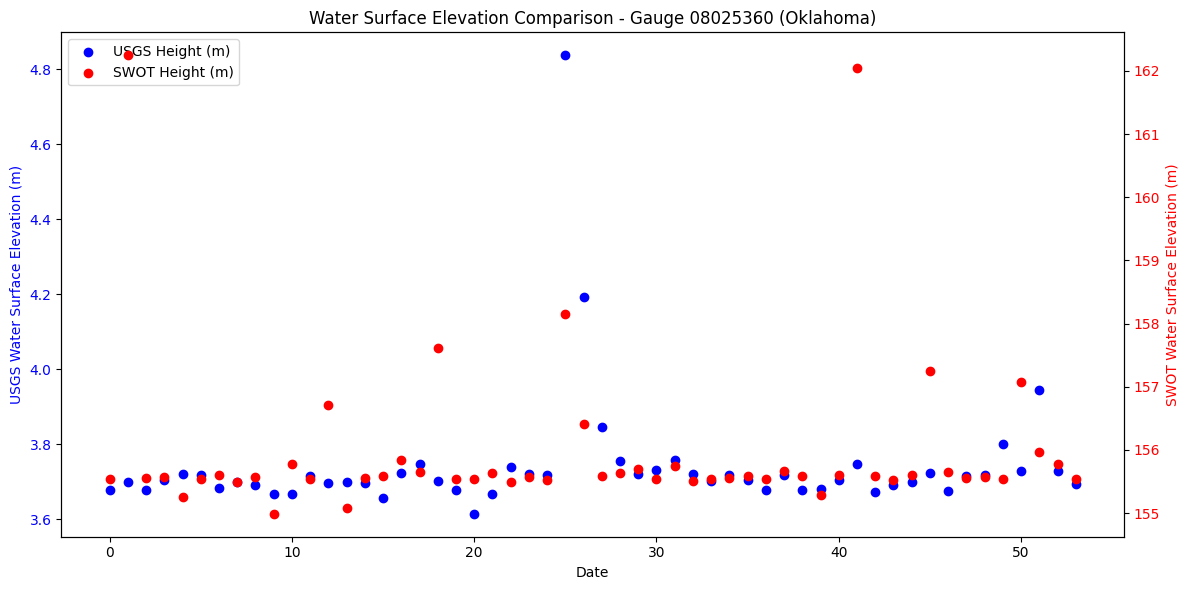

In [ ]:
import matplotlib.pyplot as plt
if 'usgs_height_m' in merged_df.columns:
  # Plotting section
  fig, ax1 = plt.subplots(figsize=(12, 6))

                  # Plot USGS height on left y-axis
  ax1.scatter(merged_df.index, merged_df['usgs_height_m'],
                          color='blue', label='USGS Height (m)')
  ax1.set_xlabel('Date')
  ax1.set_ylabel('USGS Water Surface Elevation (m)', color='blue')
  ax1.tick_params(axis='y', labelcolor='blue')

                  # Create second y-axis for SWOT height
  ax2 = ax1.twinx()
  ax2.scatter(merged_df.index, merged_df['swot_height_m'],
                          color='red', label='SWOT Height (m)')
  ax2.set_ylabel('SWOT Water Surface Elevation (m)', color='red')
  ax2.tick_params(axis='y', labelcolor='red')

                  # Add title and legend
  plt.title(f'Water Surface Elevation Comparison - Gauge {gauge_no} ({state})')
  lines1, labels1 = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

                  # Rotate x-axis labels for better readability
  plt.xticks(rotation=45)

                  # Adjust layout to prevent label overlap
  plt.tight_layout()
  plt.show()

## For Downloading daily data and merging

In [ ]:
import pandas as pd
import os
from dataretrieval import nwis
import re
import matplotlib.pyplot as plt

# [Your existing folder definitions and extract_gauge_number function remain unchanged]
folders = {
    'TX': 'Texas',
    'LU': 'Louisiana',
    'OK': 'Oklahoma'
}


# Process each folder
all_data = {}
for folder, state in folders.items():
    folder_path = f'/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/{folder}'
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} not found")
        continue

    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            print(file_path)
            swot_df = pd.read_csv(file_path, comment='#', sep=',', engine='python')

            usgs_link = swot_df['usgs_gage_link'].iloc[0]
            gauge_no = extract_gauge_number(usgs_link)

            if not gauge_no:
                print(f"Warning: Could not extract gauge number from {usgs_link} in {filename}")
                continue

            try:
                # [Your existing USGS data retrieval and processing remains unchanged up to the merge]

                usgs_df = nwis.get_record(
                    sites=gauge_no,
                    service='dv',
                    start='2023-01-01',
                    end='2025-04-01',
                    parameterCd=['00060', '00065']
                )


                # if usgs_df is empty  or only one column skip the loop this
                if usgs_df.empty or len(usgs_df.columns)==0:
                  print(f"Warning: No data found for gauge {gauge_no} in {filename}")
                  continue

                # check if we have 0006_Mean and 00065_Mean
                if '00065_Mean' in usgs_df.columns:
                  #usgs_df = usgs_df[usgs_df['00065_Mean_cd'] != 'P']
                  usgs_df = usgs_df.rename(columns={
                      '00065_Mean': 'usgs_height_ft'
                  }).filter(['usgs_height_ft'])


                  usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048,3)

                  usgs_df = usgs_df.drop(columns=['usgs_height_ft'])
                elif '00060_Mean' in usgs_df.columns:
                  usgs_df = usgs_df.rename(columns={
                      '00060_Mean': 'usgs_flow_cfs'
                  }).filter(['usgs_flow_cfs'])
                  usgs_df['usgs_flow_m3s'] = round(usgs_df['usgs_flow_cfs'] * 0.028316847,3)
                  usgs_df = usgs_df.drop(columns=['usgs_flow_cfs'])
                elif '00065_Maximum' in usgs_df.columns:
                  #usgs_df = usgs_df[usgs_df['00065_Maximum_cd'] != 'P']
                  usgs_df = usgs_df.rename(columns={
                      '00065_Maximum': 'usgs_height_ft'
                  }).filter(['usgs_height_ft'])
                  usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048,3)
                  usgs_df = usgs_df.drop(columns=['usgs_height_ft'])
                elif '00065_primary sensor_Mean' in usgs_df.columns:
                  #usgs_df = usgs_df[usgs_df['00065_primary sensor_Mean_cd'] != 'P']
                  usgs_df = usgs_df.rename(columns={
                      '00065_primary sensor_Mean': 'usgs_height_ft'
                  }).filter(['usgs_height_ft'])
                  usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048,3)
                  usgs_df = usgs_df.drop(columns=['usgs_height_ft'])

                else:
                  usgs_df = usgs_df.rename(columns={
                    '00060_Mean': 'usgs_flow_cfs',
                    '00065_Mean': 'usgs_height_ft'
                  }).filter(['usgs_flow_cfs', 'usgs_height_ft'])

                  usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048, 3)
                  usgs_df = usgs_df.drop(columns=['usgs_height_ft'])

                  usgs_df['usgs_flow_m3s'] = round(usgs_df['usgs_flow_cfs'] * 0.028316847, 3)
                  usgs_df = usgs_df.drop(columns=['usgs_flow_cfs'])

                swot_df['date'] = pd.to_datetime(swot_df['datetime']).dt.date
                usgs_df.index = usgs_df.index.date

                merged_df = swot_df.merge(
                    usgs_df,
                    left_on='date',
                    right_index=True,
                    how='right'
                )
                merged_df['state'] = state
                #merged_df = merged_df.drop(columns=['date'])

                if 'usgs_height_m' in merged_df.columns:

                  # Plotting section
                  fig, ax1 = plt.subplots(figsize=(12, 6))

                  # Plot USGS height on left y-axis
                  ax1.scatter(merged_df.index, merged_df['usgs_height_m'],
                          color='blue', label='USGS Height (m)')
                  ax1.set_xlabel('Date')
                  ax1.set_ylabel('USGS Water Surface Elevation (m)', color='blue')
                  ax1.tick_params(axis='y', labelcolor='blue')

                  # Create second y-axis for SWOT height
                  ax2 = ax1.twinx()
                  ax2.scatter(merged_df.index, merged_df['swot_height_m'],
                          color='red', label='SWOT Height (m)')
                  ax2.set_ylabel('SWOT Water Surface Elevation (m)', color='red')
                  ax2.tick_params(axis='y', labelcolor='red')

                  # Add title and legend
                  plt.title(f'Water Surface Elevation Comparison - Gauge {gauge_no} ({state})')
                  lines1, labels1 = ax1.get_legend_handles_labels()
                  lines2, labels2 = ax2.get_legend_handles_labels()
                  ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

                  # Rotate x-axis labels for better readability
                  plt.xticks(rotation=45)

                  # Adjust layout to prevent label overlap
                  plt.tight_layout()

                  # Save the plot
                  output_folder = f'/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results/{state}'
                  os.makedirs(output_folder, exist_ok=True)
                  plot_filename = os.path.join(output_folder, f'{gauge_no}_elevation_comparison.png')
                  plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
                  plt.close()  # Close the figure to free memory
                  print(f"Saved plot for gauge {gauge_no} to {plot_filename}")

                  output_filename = os.path.join(output_folder, f'{gauge_no}_merged.csv')
                  merged_df.to_csv(output_filename, index=False)

            except Exception as e:
              print(f"Error processing gauge {gauge_no} in {filename}: {e}")

    output_filename = os.path.join(output_folder, f'{gauge_no}_merged.csv')
    merged_df.to_csv(output_filename, index=False)
    print(f"Saved merged data for gauge {gauge_no} to {output_filename}")
print("Processing complete!")



/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/SWOT-74242300751-timeseries.csv
Saved plot for gauge 07227500 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results/Texas/07227500_elevation_comparison.png
/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/USGS-07227700-timeseries.csv
/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/USGS-07228000-timeseries (2).csv
Saved plot for gauge 07228000 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results/Texas/07228000_elevation_comparison.png
/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/USGS-07228000-timeseries (3).csv
Saved plot for gauge 07228000 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results/Texas/07228000_elevation_comparison.png
/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/SWOT-7422900017

In [ ]:
usgs_df = nwis.get_record(
                    sites="08057000",
                    service='dv',  # 'dv' for daily values instead of 'iv' (instantaneous)
                    start='2023-01-01',
                    end='2025-04-01',
                    parameterCd=['00060', '00065']  # 00060 = discharge, 00065 = gage height
                )


print(usgs_df.head(5))
if '00065_Mean' in usgs_df.columns:

    usgs_df = usgs_df.rename(columns={
                      '00065_Mean': 'usgs_height_ft',
                      '00065_Mean_cd': '00065_Mean_cd'
                  }).filter(['usgs_height_ft'])


    usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048,3)
                  ## drop rows where the 00065_Mean_cd is equal to P

    usgs_df = usgs_df.drop(columns=['usgs_height_ft'])


                            site_no  00060_radar_Maximum  \
datetime                                                   
2023-01-01 00:00:00+00:00  08057000                931.0   
2023-01-02 00:00:00+00:00  08057000                567.0   
2023-01-03 00:00:00+00:00  08057000                558.0   
2023-01-04 00:00:00+00:00  08057000                554.0   
2023-01-05 00:00:00+00:00  08057000                527.0   

                          00060_radar_Maximum_cd  00060_radar_Minimum  \
datetime                                                                
2023-01-01 00:00:00+00:00                      A                510.0   
2023-01-02 00:00:00+00:00                      A                499.0   
2023-01-03 00:00:00+00:00                      A                507.0   
2023-01-04 00:00:00+00:00                      A                498.0   
2023-01-05 00:00:00+00:00                      A                480.0   

                          00060_radar_Minimum_cd  00060_radar_Mean 

In [ ]:
import pandas as pd
import os
from dataretrieval import nwis
import re
import matplotlib.pyplot as plt
import numpy as np

# Function to extract gauge number from a link
def extract_gauge_number(link):
    match = re.search(r'\d{8}', link)
    return match.group(0) if match else None

folders = {
    'TX': 'Texas',
    'LU': 'Louisiana',
    'OK': 'Oklahoma'
}

# Function to calculate the average of the three nearest USGS values
def get_avg_of_three_nearest(df, time, column):
    if df.empty or column not in df.columns:
        return np.nan
    # Calculate absolute time differences between the target time and index
    diffs = np.abs(df.index - time)
    # Get indices of the three smallest differences
    indices = diffs.argsort()[:3]
    # Extract the values at those indices and compute the mean
    nearest_values = df.iloc[indices][column]
    return nearest_values.mean()

# Process each folder
for folder, state in folders.items():
    folder_path = f'/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/{folder}'
    if not os.path.exists(folder_path):
        print(f"Warning: Folder {folder_path} not found")
        continue

    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            print(f"Processing {file_path}")
            swot_df = pd.read_csv(file_path, comment='#', sep=',', engine='python')

            # Extract USGS gauge number
            usgs_link = swot_df['usgs_gage_link'].iloc[0]
            gauge_no = extract_gauge_number(usgs_link)

            if not gauge_no:
                print(f"Warning: Could not extract gauge number from {usgs_link} in {filename}")
                continue

            try:
                # Fetch sub-daily USGS data
                usgs_df = nwis.get_record(
                    sites=gauge_no,
                    service='iv',  # Instantaneous values
                    start='2023-01-01',
                    end='2025-04-01',
                    parameterCd=['00060', '00065']
                )

                # Check if USGS data is empty
                if usgs_df.empty:
                    print(f"Warning: No data found for gauge {gauge_no} in {filename}")
                    continue

                # Process USGS instantaneous data
                # Filter out provisional data
                if '00065' in usgs_df.columns and '00065_cd' in usgs_df.columns:
                    usgs_df = usgs_df[usgs_df['00065_cd'] != 'P']
                if '00060' in usgs_df.columns and '00060_cd' in usgs_df.columns:
                    usgs_df = usgs_df[usgs_df['00060_cd'] != 'P']

                # Rename and convert units
                if '00065' in usgs_df.columns:
                    usgs_df = usgs_df.rename(columns={'00065': 'usgs_height_ft'})
                    usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048, 3)
                    usgs_df = usgs_df.drop(columns=['usgs_height_ft'])
                if '00060' in usgs_df.columns:
                    usgs_df = usgs_df.rename(columns={'00060': 'usgs_flow_cfs'})
                    usgs_df['usgs_flow_m3s'] = round(usgs_df['usgs_flow_cfs'] * 0.028316847, 3)
                    usgs_df = usgs_df.drop(columns=['usgs_flow_cfs'])

                # Keep only the processed columns
                columns_to_keep = [col for col in ['usgs_height_m', 'usgs_flow_m3s'] if col in usgs_df.columns]
                if not columns_to_keep:
                    print(f"Warning: No valid data columns for gauge {gauge_no} in {filename}")
                    continue
                usgs_df = usgs_df[columns_to_keep]

                # Set SWOT dataframe index to full datetime
                swot_df['datetime'] = pd.to_datetime(swot_df['datetime'])
                swot_df = swot_df.set_index('datetime')

                # Calculate averages of three nearest USGS values
                if 'usgs_height_m' in usgs_df.columns:
                    swot_df['usgs_height_m_avg'] = swot_df.index.map(
                        lambda t: get_avg_of_three_nearest(usgs_df, t, 'usgs_height_m')
                    )
                if 'usgs_flow_m3s' in usgs_df.columns:
                    swot_df['usgs_flow_m3s_avg'] = swot_df.index.map(
                        lambda t: get_avg_of_three_nearest(usgs_df, t, 'usgs_flow_m3s')
                    )

                # Add state column
                swot_df['state'] = state

                # Plotting section (for height comparison)
                if 'usgs_height_m_avg' in swot_df.columns:
                    fig, ax1 = plt.subplots(figsize=(12, 6))
                    # Plot averaged USGS height
                    ax1.scatter(swot_df.index, swot_df['usgs_height_m_avg'],
                                color='blue', label='USGS Height Avg (m)')
                    ax1.set_xlabel('Date and Time')
                    ax1.set_ylabel('USGS Water Surface Elevation (m)', color='blue')
                    ax1.tick_params(axis='y', labelcolor='blue')

                    # Plot SWOT height
                    ax2 = ax1.twinx()
                    ax2.scatter(swot_df.index, swot_df['swot_height_m'],
                                color='red', label='SWOT Height (m)')
                    ax2.set_ylabel('SWOT Water Surface Elevation (m)', color='red')
                    ax2.tick_params(axis='y', labelcolor='red')

                    # Add title and legend
                    plt.title(f'Water Surface Elevation Comparison - Gauge {gauge_no} ({state})')
                    lines1, labels1 = ax1.get_legend_handles_labels()
                    lines2, labels2 = ax2.get_legend_handles_labels()
                    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
                    plt.xticks(rotation=45)

                    # Save the plot
                    output_folder = f'/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_v2/{state}'
                    os.makedirs(output_folder, exist_ok=True)
                    plot_filename = os.path.join(output_folder, f'{gauge_no}_elevation_comparison.png')
                    plt.savefig(plot_filename, dpi=300, bbox_inches='tight')
                    plt.close()
                    print(f"Saved plot for gauge {gauge_no} to {plot_filename}")

                # Save the updated dataframe
                output_filename = os.path.join(output_folder, f'{gauge_no}_merged.csv')
                swot_df.to_csv(output_filename, index=True)  # Keep datetime index
                print(f"Saved merged data for gauge {gauge_no} to {output_filename}")

            except Exception as e:
                print(f"Error processing gauge {gauge_no} in {filename}: {e}")

print("Processing complete!")

Processing /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/SWOT-74242300751-timeseries.csv
Saved plot for gauge 07227500 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_v2/Texas/07227500_elevation_comparison.png
Saved merged data for gauge 07227500 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_v2/Texas/07227500_merged.csv
Processing /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/USGS-07227700-timeseries.csv
Saved plot for gauge 07227700 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_v2/Texas/07227700_elevation_comparison.png
Saved merged data for gauge 07227700 to /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results_v2/Texas/07227700_merged.csv
Processing /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/TX/USGS-07228000-timeseries (2).csv
Saved plot for ga

KeyboardInterrupt: 

In [ ]:
 gauge_no='08067250'

usgs_df = nwis.get_record(
                    sites=gauge_no,
                    service='dv',
                    start='2023-01-01',
                    end='2025-04-01',
                    parameterCd=['00060', '00065']
                )




 # check if we have 0006_Mean and 00065_Mean
if '00060_Mean' not in usgs_df.columns:
  usgs_df = usgs_df.rename(columns={
                      '00065_Mean': 'usgs_height_ft'
                  }).filter(['usgs_height_ft'])

  usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048,3)
  usgs_df = usgs_df.drop(columns=['usgs_height_ft'])
elif '00065_Mean' not in usgs_df.columns:
  usgs_df = usgs_df.rename(columns={
                      '00060_Mean': 'usgs_flow_cfs'
                  }).filter(['usgs_flow_cfs'])
  usgs_df['usgs_flow_m3s'] = round(usgs_df['usgs_flow_cfs'] * 0.028316847,3)
  usgs_df = usgs_df.drop(columns=['usgs_flow_cfs'])
else:

  usgs_df = usgs_df.rename(columns={
                    '00060_Mean': 'usgs_flow_cfs',
                    '00065_Mean': 'usgs_height_ft'
                  }).filter(['usgs_flow_cfs', 'usgs_height_ft'])

  usgs_df['usgs_height_m'] = round(usgs_df['usgs_height_ft'] * 0.3048, 3)
  usgs_df = usgs_df.drop(columns=['usgs_height_ft'])

  usgs_df['usgs_flow_m3s'] = round(usgs_df['usgs_flow_cfs'] * 0.028316847, 3)
  usgs_df = usgs_df.drop(columns=['usgs_flow_cfs'])


swot_df['date'] = pd.to_datetime(swot_df['datetime']).dt.date
usgs_df.index = usgs_df.index.date

merged_df = swot_df.merge(
                    usgs_df,
                    left_on='date',
                    right_index=True,
                    how='right'
                )
merged_df['state'] = state
                #merged_df = merged_df.drop(columns=['date'])

                # Plotting section
fig, ax1 = plt.subplots(figsize=(12, 6))

                # Plot USGS height on left y-axis
ax1.scatter(merged_df.index, merged_df['usgs_height_m'],
                        color='blue', label='USGS Height (m)')
ax1.set_xlabel('Date')
ax1.set_ylabel('USGS Water Surface Elevation (m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

                # Create second y-axis for SWOT height
ax2 = ax1.twinx()
ax2.scatter(merged_df.index, merged_df['swot_height_m'],
                        color='red', label='SWOT Height (m)')
ax2.set_ylabel('SWOT Water Surface Elevation (m)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

                # Add title and legend
plt.title(f'Water Surface Elevation Comparison - Gauge {gauge_no} ({state})')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

                # Rotate x-axis labels for better readability
plt.xticks(rotation=45)

                # Adjust layout to prevent label overlap
plt.tight_layout()






KeyError: 'usgs_height_ft'

In [ ]:
usgs_df.empty

True

## generate the data sample

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from pathlib import Path

def create_sliding_windows(data, window_size=128, stride=7):
    """
    Create sliding windows from time series data
    Args:
        data: numpy array of time series data
        window_size: size of each window (128 in this case)
        stride: step size between windows (7 days)
    Returns:
        numpy array of shape (num_windows, window_size)
    """


    if len(data) < window_size:
        return np.array([])

    num_windows = ((len(data) - window_size) // stride) + 1
    windows = np.zeros((num_windows, window_size))

    for i in range(num_windows):
        start_idx = i * stride
        windows[i] = data[start_idx:start_idx + window_size]

    return windows






def process_usgs_data(root_dir):
    """
    Process all merged.csv files and create training dataset
    Args:
        root_dir: root directory containing state subfolders with CSV files
    Returns:
        torch tensor of shape [x, 1, 128]
    """
    all_windows = []

    # Walk through directory tree
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith("merged.csv"):
                file_path = os.path.join(root, file)
                #print(f"Processing: {file_path}")

                # Read CSV file
                try:
                    df = pd.read_csv(file_path)

                    # Check if usgs_height_m column exists
                    if "usgs_height_m" not in df.columns:
                        print(f"Warning: 'usgs_height_m' not found in {file_path}")
                        continue

                    # Extract height data
                    height_data = df["usgs_height_m"].dropna().values
                    # put negatives as nan
                    height_data[height_data < 0] = np.nan

                    # remove nan values
                    height_data = height_data[~np.isnan(height_data)]
                    print(height_data.max(), height_data.min(), height_data.mean())

                    # Create sliding windows
                    windows = create_sliding_windows(height_data)

                    if len(windows) > 0:
                        all_windows.append(windows)
                        #print(f"Created {len(windows)} windows from {file_path}")
                    else:
                        print(f"Not enough data for windows in {file_path}")

                except Exception as e:
                    print(f"Error processing {file_path}: {str(e)}")
                    continue





    # Combine all windows
    if not all_windows:
        raise ValueError("No valid data found in any CSV files")

    combined_windows = np.concatenate(all_windows, axis=0)

    # Convert to torch tensor and reshape to [x, 1, 128]
    tensor_data = torch.tensor(combined_windows, dtype=torch.float32)
    tensor_data = tensor_data.unsqueeze(1)  # Add channel dimension

    print(f"Final dataset shape: {tensor_data.shape}")
    return tensor_data



# Example usage
def main():
    # Set your root directory containing state subfolders
    root_directory = "/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results"

    try:
        # Process data and get training dataset
        training_data = process_usgs_data(root_directory)

        # Save the tensor if needed
        torch.save(training_data, "usgs_training_data_v2.pt")
        print("Training data saved to usgs_training_data.pt")

    except Exception as e:
        print(f"Error in processing: {str(e)}")


main()

23.07 19.675 19.990720818291216
14.789 1.308 3.364962332928311
5.621 1.853 2.2416585662211426
9.848 1.789 4.072114634146342
7.605 0.695 1.0790977995110025
9.534 0.43 1.1038468137254902
7.105 1.256 2.4120995203836935
3.484 0.658 0.8491405867970659
11.421 1.975 2.6246524390243904
11.561 1.78 3.27739709762533
5.13 2.954 3.349086165048545
4.517 0.436 0.7177712177121771
6.971 3.459 4.047203163017032
8.013 0.354 1.5996117084826762
10.638 0.89 2.1883622141997594
12.774 3.28 4.858825316455697
13.756 1.1 3.7073624078624077
3.203 0.21 0.5159447779111644
5.907 0.866 1.3197995169082124
3.06 0.293 0.4885507765830347
3.999 0.408 0.7995567567567567
4.389 1.222 1.5150260223048326
7.285 0.387 1.0223422655298415
4.828 1.756 2.1611652593486133
6.983 0.262 0.8455140073081608
14.158 2.728 4.372762773722628
36.11 28.319 29.161025516403402
14.292 1.14 3.2983264058679707
2.277 0.302 0.47630413625304135
4.877 3.264 3.585913625304137
2.761 0.119 0.34588985148514856
1.362 0.192 0.4382436604189636
1.259 0.68 0.76

In [ ]:
root_directory = "/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results"



for root, dirs, files in os.walk(root_directory):
  print(root, dirs, files)
  # count the files ending with .csv
  print(len([file for file in files if file.endswith(".csv")]))
  # count the files ending with png
  print(len([file for file in files if file.endswith(".png")]))

/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results ['Texas', 'Louisiana', 'Oklahoma'] []
0
0
/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT-Gauge/Results/Texas [] ['08088610_merged.csv', '08066250_merged.csv', '08080505_merged.csv', '08067000_merged.csv', '08160400_merged.csv', '08162500_merged.csv', '08053000_merged.csv', '08159200_merged.csv', '08162000_merged.csv', '08108700_merged.csv', '08090905_merged.csv', '08374550_merged.csv', '08055560_merged.csv', '08057410_merged.csv', '08062500_merged.csv', '08066500_merged.csv', '08065000_merged.csv', '08082500_merged.csv', '08088000_merged.csv', '08089000_merged.csv', '08090800_merged.csv', '08091000_merged.csv', '08098290_merged.csv', '08093100_merged.csv', '08096500_merged.csv', '08111500_merged.csv', '08111850_merged.csv', '08116650_merged.csv', '08159500_merged.csv', '08158000_merged.csv', '07227500_merged.csv', '07228000_elevation_comparison.png', '07300000_elevation_comparison.p

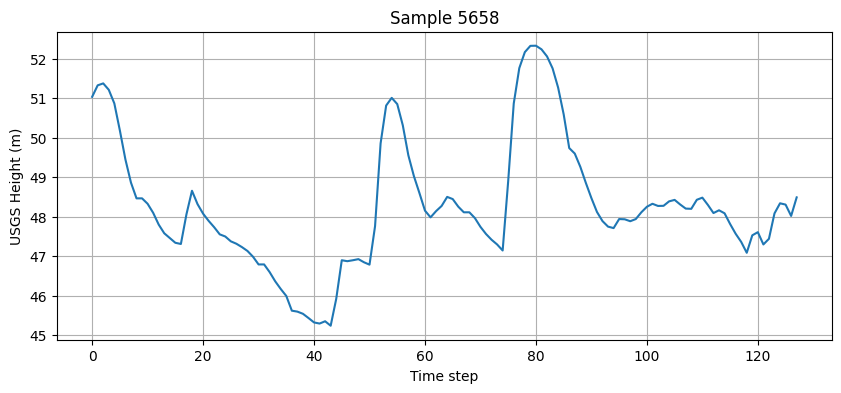

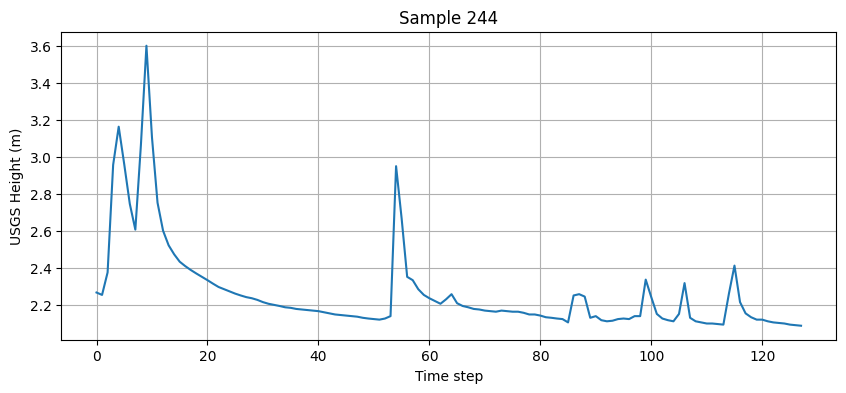

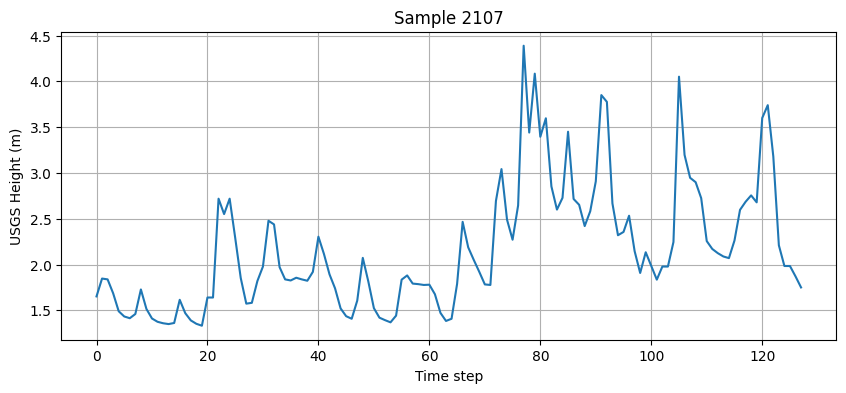

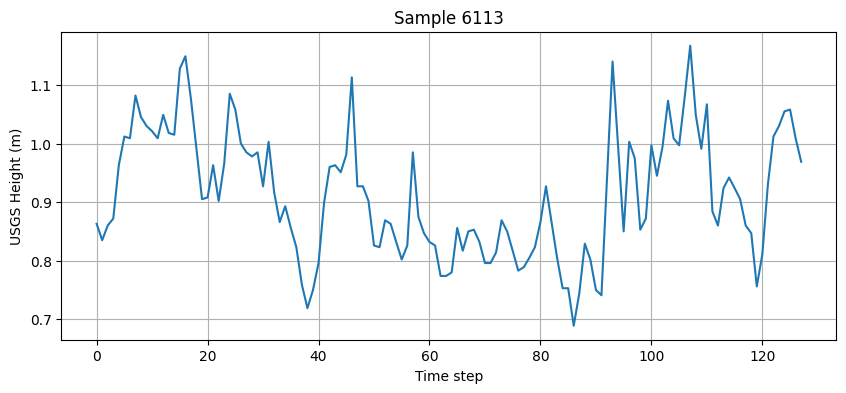

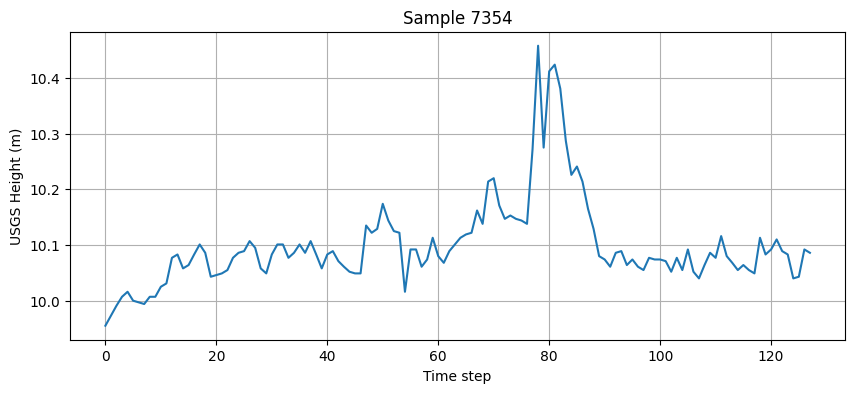

In [ ]:
# prompt: for random samples in the dataset plot the them to compare

import matplotlib.pyplot as plt
import random

def plot_random_samples(data, num_samples=5):
    """Plots a specified number of random samples from the dataset."""
    num_to_plot = min(num_samples, len(data))  # Ensure we don't try to plot more samples than exist
    random_indices = random.sample(range(len(data)), num_to_plot)

    for i in random_indices:
        plt.figure(figsize=(10, 4))  # Adjust figure size as needed
        plt.plot(data[i].squeeze())  # Squeeze to remove the channel dimension
        plt.title(f"Sample {i + 1}")
        plt.xlabel("Time step")
        plt.ylabel("USGS Height (m)")
        plt.grid(True)
        plt.show()

# Assuming 'training_data' is your torch tensor from the previous code
# Load the data if you haven't already
try:
    training_data = torch.load("usgs_training_data_v2.pt")
    plot_random_samples(training_data)
except FileNotFoundError:
    print("Error: 'usgs_training_data.pt' not found. Please make sure the file exists in the current directory or run the data processing code first.")
except Exception as e:
    print(f"An error occurred: {e}")


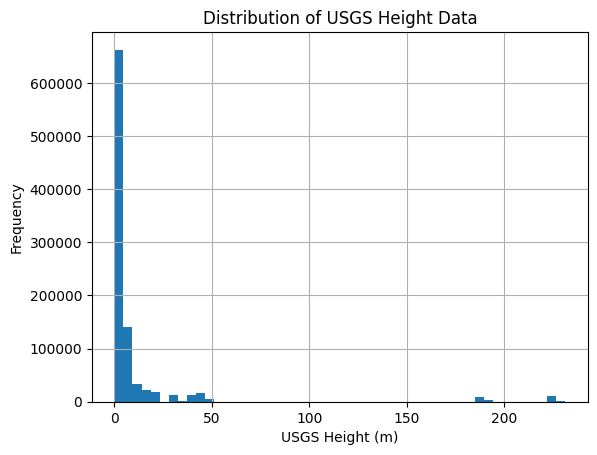

In [ ]:
# prompt: plot the distribution of datasamples histogram

import numpy as np
import matplotlib.pyplot as plt

# Assuming 'training_data' is your torch tensor
# Load the data if you haven't already
try:
    training_data = torch.load("usgs_training_data_v2.pt")

    # Convert the tensor to a NumPy array for plotting
    data_np = training_data.numpy()

    # Flatten the data for the histogram
    flattened_data = data_np.flatten()

    # Create the histogram
    plt.hist(flattened_data, bins=50)  # Adjust the number of bins as needed

    plt.xlabel("USGS Height (m)")
    plt.ylabel("Frequency")
    plt.title("Distribution of USGS Height Data")
    plt.grid(True)
    plt.show()

except FileNotFoundError:
    print("Error: 'usgs_training_data.pt' not found. Please make sure the file exists in the current directory or run the data processing code first.")
except Exception as e:
    print(f"An error occurred: {e}")


In [ ]:
# prompt: mount gdrive

drive.mount('/content/drive')


Mounted at /content/drive


## 4 channel data

In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from pathlib import Path

def create_sliding_windows(data, window_size=64, stride=7):
    """
    Create sliding windows from time series data with multiple features.

    Args:
        data: numpy array of shape [time_steps, num_features]
        window_size: size of each window (default: 64)
        stride: step size between windows (default: 7)

    Returns:
        numpy array of shape [num_windows, window_size, num_features]
    """
    if data.shape[0] < window_size:
        return np.array([])

    num_windows = ((data.shape[0] - window_size) // stride) + 1
    windows = np.zeros((num_windows, window_size, data.shape[1]))

    for i in range(num_windows):
        start_idx = i * stride
        windows[i] = data[start_idx:start_idx + window_size]

    return windows

def process_usgs_data(root_dir):
    """
    Process all merged.csv files and create a training dataset with 4 channels.

    Args:
        root_dir: root directory containing state subfolders with CSV files

    Returns:
        torch tensor of shape [x, 4, 64], where 4 is the number of channels
    """
    all_windows = []

    for root, dirs, files in os.walk(root_dir):

        for file in files:
            if file.endswith("merged.csv"):
                file_path = os.path.join(root, file)
                try:
                    df = pd.read_csv(file_path)
                    print(f"Processing: {file_path}")
                    print(df.columns)

                    # Define required columns
                    required_columns = ["usgs_height_m", "terrain_elevation_m", "terrain_slope_deg", "swot_width_m"]
                    if not all(col in df.columns for col in required_columns):
                        print(f"Warning: Missing columns in {file_path}")
                        continue

                    # Preprocess height columns: set negative values to NaN
                    df["usgs_height_m"] = df["usgs_height_m"].apply(lambda x: x if x >= 0 else np.nan)
                    df["terrain_elevation_m"] = df["terrain_elevation_m"].apply(lambda x: x if x >= 0 else np.nan)

                    # Drop rows where usgs_height, usgs_height_m, or terrain_slope_deg are NaN
                    df = df.dropna(subset=["usgs_height_m", "terrain_elevation_m", "terrain_slope_deg"])
                    print(df.columns)
                    # Compute median of swot_width_m for the entire CSV (used when a window has all NaNs)
                    swot_width_median = df["swot_width_m"].median(skipna=True)
                    if pd.isna(swot_width_median):
                        print(f"Warning: All swot_width_m values are NaN in {file_path}, skipping")
                        continue

                    # Extract the four channels
                    data = df[required_columns].values  # Shape: [time_steps, 4]

                    # Create sliding windows: [num_windows, 64, 4]
                    windows = create_sliding_windows(data, window_size=64, stride=7)
                    if len(windows) == 0:
                        print(f"Not enough data for windows in {file_path}")
                        continue

                    # Handle NaNs in swot_width_m per window
                    for i in range(windows.shape[0]):
                        swot_width_window = windows[i, :, 3]  # swot_width_m is the 4th channel (index 3)
                        non_nan_values = swot_width_window[~np.isnan(swot_width_window)]
                        if len(non_nan_values) > 0:
                            # If there are non-NaN values, fill NaNs with the average of non-NaN values in this window
                            avg = np.mean(non_nan_values)
                            windows[i, :, 3] = np.where(np.isnan(swot_width_window), avg, swot_width_window)
                        else:
                            # If all values are NaN, fill with the median of the entire CSV
                            windows[i, :, 3] = swot_width_median

                    all_windows.append(windows)

                except Exception as e:
                    print(f"Error processing {file_path}: {str(e)}")
                    continue

    print(f"Found {len(all_windows)} windows")
    if not all_windows:
        raise ValueError("No valid data found in any CSV files")

    # Combine all windows into a single array
    combined_windows = np.concatenate(all_windows, axis=0)  # Shape: [num_windows, 64, 4]

    # Convert to torch tensor and adjust dimensions to [x, 4, 64]
    tensor_data = torch.tensor(combined_windows, dtype=torch.float32)
    tensor_data = tensor_data.permute(0, 2, 1)  # From [num_windows, 64, 4] to [num_windows, 4, 64]

    print(f"Final dataset shape: {tensor_data.shape}")
    return tensor_data

def main():
    # Set your root directory containing state subfolders
    #/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT_USGS_MERIT
    root_directory = "/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT_USGS_MERIT"

    try:
        # Process data and get training dataset
        training_data = process_usgs_data(root_directory)

        # Save the tensor
        torch.save(training_data, "usgs_training_data_64_4_v1.pt")
        print("Training data saved to usgs_training_data_64_4_v1.pt")

    except Exception as e:
        print(f"Error in processing: {str(e)}")


main()

Processing: /content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT_USGS_MERIT/Louisiana/07381450_merged.csv
Index(['datetime', 'tz_cd', 'swot_reach_id', 'latitude', 'longitude',
       'swot_height_m', 'swot_height_u_m', 'swot_height_r_u', 'swot_width_m',
       'swot_width_u_m', 'swot_slope', 'swot_slope_u', 'swot_slope_r_u',
       'swot_slope2', 'swot_dark_frac', 'swot_n_good_nod', 'swot_reach_q_b',
       'swot_xovr_cal_q', 'swot_xtrk_dist', 'ice_clim_f', 'data_quality',
       'date_retrieved', 'swot_data_collection', 'sword_version',
       'usgs_gage_link', 'river_name', 'date', 'usgs_height_m', 'state',
       'terrain_elevation_m', 'terrain_slope_deg'],
      dtype='object')
Index(['datetime', 'tz_cd', 'swot_reach_id', 'latitude', 'longitude',
       'swot_height_m', 'swot_height_u_m', 'swot_height_r_u', 'swot_width_m',
       'swot_width_u_m', 'swot_slope', 'swot_slope_u', 'swot_slope_r_u',
       'swot_slope2', 'swot_dark_frac', 'swot_n_good_nod', 'swot_reach_q

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path

def fill_nans_swot_width(df, window_size_small=21, window_size_large=150):
    """
    Fill NaNs in swot_width_m using a 21-size window average, falling back to 150-size window average.

    Args:
        df: pandas DataFrame containing swot_width_m column
        window_size_small: size of the smaller rolling window
        window_size_large: size of the larger rolling window

    Returns:
        pandas Series with filled NaN values
    """
    swot_width = df['swot_width_m'].copy()

    # First attempt: fill with 21-size window rolling mean
    rolling_mean_small = swot_width.rolling(window=window_size_small, min_periods=1, center=True).mean()
    swot_width = swot_width.fillna(rolling_mean_small)

    # Second attempt: fill remaining NaNs with 150-size window rolling mean
    rolling_mean_large = swot_width.rolling(window=window_size_large, min_periods=1, center=True).mean()
    swot_width = swot_width.fillna(rolling_mean_large)

    # Final fallback: fill any remaining NaNs with overall mean
    swot_width = swot_width.fillna(swot_width.mean())

    return swot_width

def process_usgs_data(root_dir):
    """
    Process all merged.csv files, fill NaNs, and concatenate data into one DataFrame.

    Args:
        root_dir: root directory containing state subfolders with CSV files

    Returns:
        concatenated DataFrame with required columns
    """
    all_data = []
    required_columns = ['terrain_slope_deg', 'terrain_elevation_m', 'usgs_height_m', 'swot_width_m']

    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith("merged.csv"):
                file_path = os.path.join(root, file)
                try:
                    df = pd.read_csv(file_path)

                    # Check for required columns
                    if not all(col in df.columns for col in required_columns):
                        print(f"Warning: Missing columns in {file_path}")
                        continue

                    # Preprocess data
                    df['usgs_height_m'] = df['usgs_height_m'].apply(lambda x: x if x >= 0 else np.nan)
                    df = df.dropna(subset=['terrain_slope_deg', 'terrain_elevation_m', 'usgs_height_m'])

                    # Fill NaNs in swot_width_m
                    df['swot_width_m'] = fill_nans_swot_width(df)

                    # Extract required columns
                    data = df[required_columns]
                    all_data.append(data)

                except Exception as e:
                    print(f"Error processing {file_path}: {str(e)}")
                    continue

    if not all_data:
        raise ValueError("No valid data found in any CSV files")

    # Concatenate all data into one DataFrame
    combined_data = pd.concat(all_data, axis=0, ignore_index=True)
    print(f"Combined data shape: {combined_data.shape}")
    return combined_data

def pca_analysis(X, feature_names):
    """
    Perform PCA analysis on the combined data.

    Args:
        X: numpy array of shape [samples, features]
        feature_names: list of feature names

    Returns:
        dict containing PCA results
    """
    # Standardize the features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Compute covariance matrix
    cov_matrix = np.cov(X_scaled.T)

    # Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

    # Sort in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # Calculate explained variance ratio
    explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

    # Project data onto principal components
    projected_data = np.dot(X_scaled, eigenvectors)

    # Component loadings
    loadings = eigenvectors * np.sqrt(eigenvalues)

    return {
        'projected_data': projected_data,
        'components': eigenvectors,
        'explained_variance_ratio': explained_variance_ratio,
        'loadings': loadings,
        'feature_names': feature_names
    }


def main():
    # Set root directory containing state subfolders
    root_directory = "/content/drive/MyDrive/Adnan-PHD/Proposal/Geospatialdatascience/SWOT_USGS_MERIT"

    try:
        # Process data: fill NaNs and combine into one DataFrame
        combined_data = process_usgs_data(root_directory)

        # Prepare data for PCA
        X = combined_data.values
        feature_names = combined_data.columns.tolist()

        # Apply PCA on combined data
        pca_results = pca_analysis(X, feature_names)

        # Print PCA results
        print("\nPCA Results for Combined Data:")
        for i, (var_ratio, component) in enumerate(zip(
            pca_results['explained_variance_ratio'],
            pca_results['components'].T)):
            print(f"Principal Component {i+1}:")
            print(f"Explained Variance Ratio: {var_ratio:.4f} ({var_ratio*100:.2f}%)")
            print("Feature Loadings:")
            for feat, loading in zip(feature_names, component):
                print(f"  {feat}: {loading:.4f}")
            print()

        # Save results to text file
        with open("pca_results_combined.txt", "w") as f:
            f.write("PCA Results for Combined Data:\n")
            for i, (var_ratio, component) in enumerate(zip(
                pca_results['explained_variance_ratio'],
                pca_results['components'].T)):
                f.write(f"\nPrincipal Component {i+1}:\n")
                f.write(f"Explained Variance Ratio: {var_ratio:.4f} ({var_ratio*100:.2f}%)\n")
                f.write("Feature Loadings:\n")
                for feat, loading in zip(feature_names, component):
                    f.write(f"  {feat}: {loading:.4f}\n")

        print("PCA results saved to pca_results_combined.txt")

    except Exception as e:
        print(f"Error in processing: {str(e)}")

if __name__ == "__main__":
    main()

Combined data shape: (61358, 4)

PCA Results for Combined Data:
Principal Component 1:
Explained Variance Ratio: 0.2697 (26.97%)
Feature Loadings:
  terrain_slope_deg: -0.5094
  terrain_elevation_m: -0.1936
  usgs_height_m: -0.5081
  swot_width_m: 0.6670

Principal Component 2:
Explained Variance Ratio: 0.2590 (25.90%)
Feature Loadings:
  terrain_slope_deg: -0.5122
  terrain_elevation_m: -0.7001
  usgs_height_m: 0.4097
  swot_width_m: -0.2823

Principal Component 3:
Explained Variance Ratio: 0.2444 (24.44%)
Feature Loadings:
  terrain_slope_deg: 0.4517
  terrain_elevation_m: -0.5740
  usgs_height_m: -0.6174
  swot_width_m: -0.2921

Principal Component 4:
Explained Variance Ratio: 0.2270 (22.70%)
Feature Loadings:
  terrain_slope_deg: -0.5236
  terrain_elevation_m: 0.3780
  usgs_height_m: -0.4390
  swot_width_m: -0.6246

PCA results saved to pca_results_combined.txt
